In [1]:
input_tce_csv_file = "/pdo/astronet-data/data/properties/tces-sector87.csv"
tess_data_dir = "/pdo/astronet-data/data/fits/sector-87/"
astro_id_to_inspect = 30081274102

In [2]:
from typing import Optional
import pandas as pd
import numpy as np
from astronet.preprocess import preprocess
import matplotlib.pyplot as plt

tce_table = pd.read_csv(input_tce_csv_file, header=0, low_memory=False)
print(f'Loaded {len(tce_table)}, downsampling to 1 id {astro_id_to_inspect}')
tce = tce_table[tce_table["Astro ID"] == astro_id_to_inspect].iloc[0]
print(tce.to_string())

def get_lightcurve(astro_id: int, aperture: Optional[str] = None) -> tuple[np.ndarray, np.ndarray]:
    aperture_key_map = {
        "s": "SAP_FLUX_SML",
        "m": "SAP_FLUX_MID",
        "l": "SAP_FLUX_LAG",
        None: "SAP_FLUX",
    }
    matching_tces = tce_table[tce_table["Astro ID"] == astro_id] # tce_table.where(tce_table["Astro ID"] == astro_id)
    try:
        _, tce = next(matching_tces.iterrows())
    except StopIteration as e:
        raise ValueError(f"Astro ID not found: {astro_id}") from e
    if "MinT" not in tce:
        tce["MinT"] = -np.inf
    if "MaxT" not in tce:
        tce["MaxT"] = np.inf
    return preprocess.read_and_process_light_curve(
        tess_data_dir,
        aperture_key_map[aperture],
        tce.File,
        tce.MinT,
        tce.MaxT,
    )

2025-09-02 12:29:03.965140: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-02 12:29:04.014506: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-02 12:29:04.015103: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-02 12:29:05.096483: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Loaded 4824, downsampling to 1 id 30081274102
TIC ID                                              300812741
SMass                                                     0.7
SRad                                                 0.697547
Tmag                                                  10.0534
planetno                                                    2
Epoc                                              1328.692691
Per                                                 11.307119
Depth                                              285.445342
Dur                                                  0.150726
SRadEst                                                   NaN
Astro ID                                          30081274102
File        /pdo/astronet-data/data/fits/sector-87/astrone...


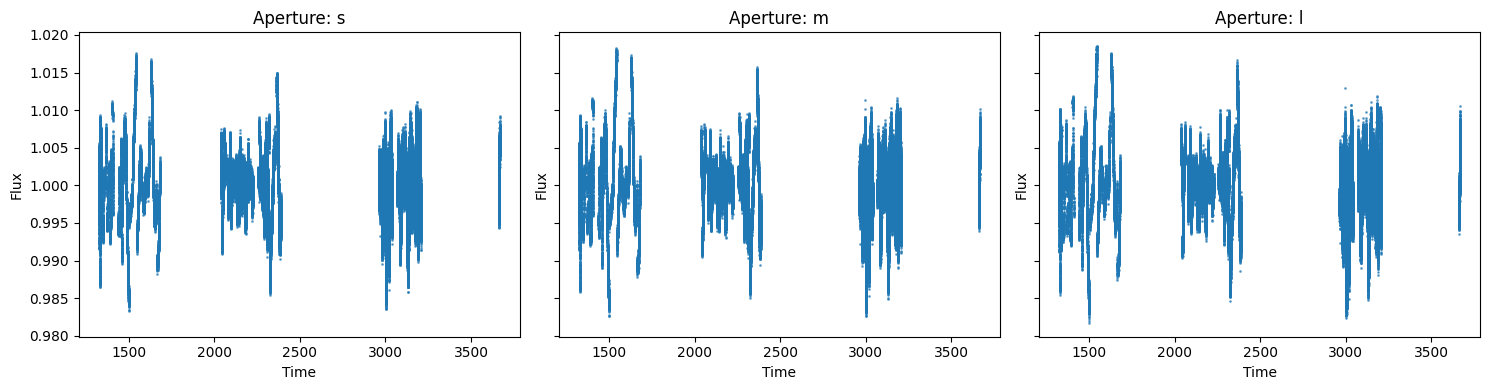

In [3]:
# Process TCE function call

# Step 1: Get aperturues
time, flux = get_lightcurve(tce['Astro ID'])
apertures = {
    's': get_lightcurve(tce['Astro ID'], aperture='s'),
    'm': get_lightcurve(tce['Astro ID'], aperture='m'),
    'l': get_lightcurve(tce['Astro ID'], aperture='l'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, (label, (t, f)) in zip(axes, apertures.items()):
    ax.plot(t, f, '.', markersize=2, alpha=0.6)
    ax.set_title(f"Aperture: {label}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Flux")

plt.tight_layout()
plt.show()

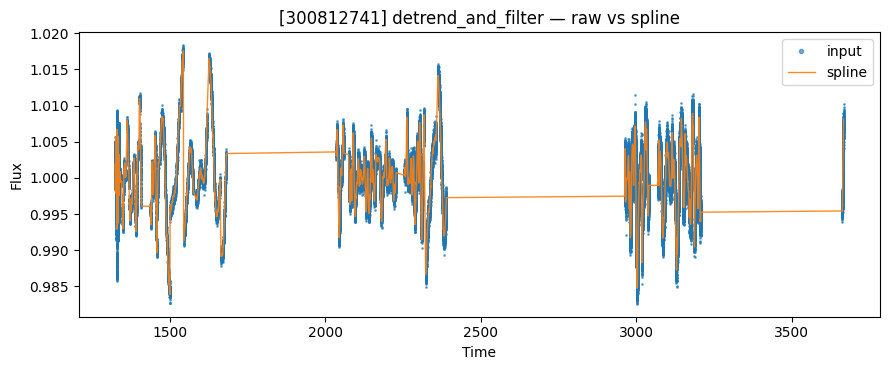

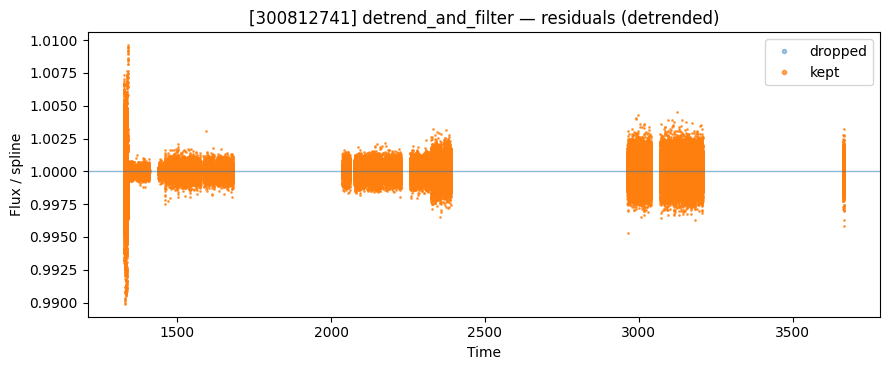

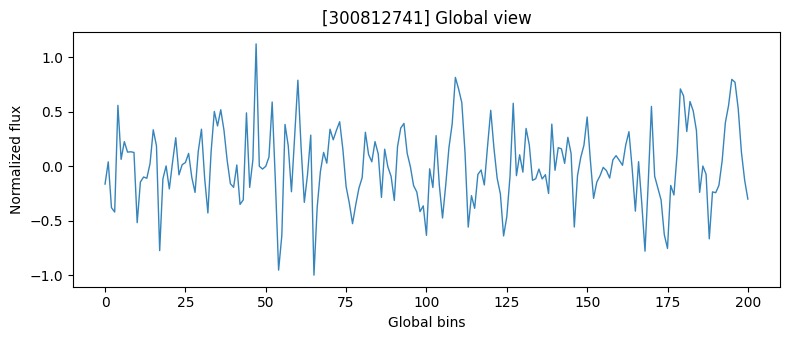

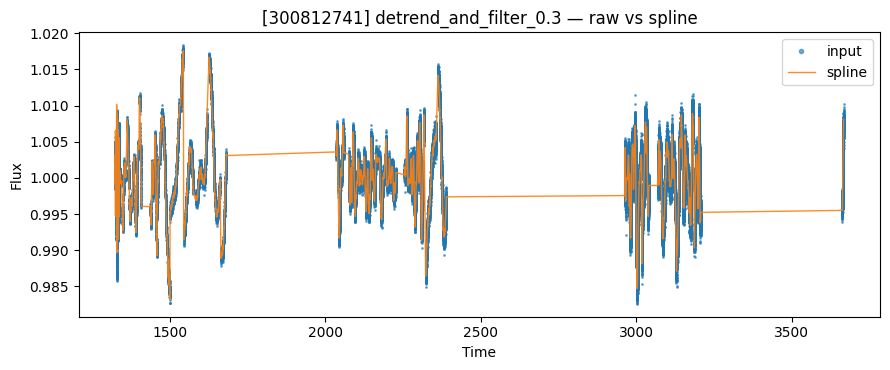

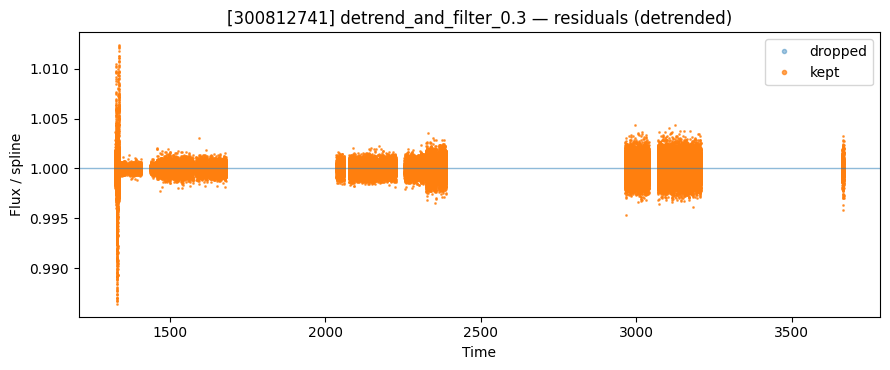

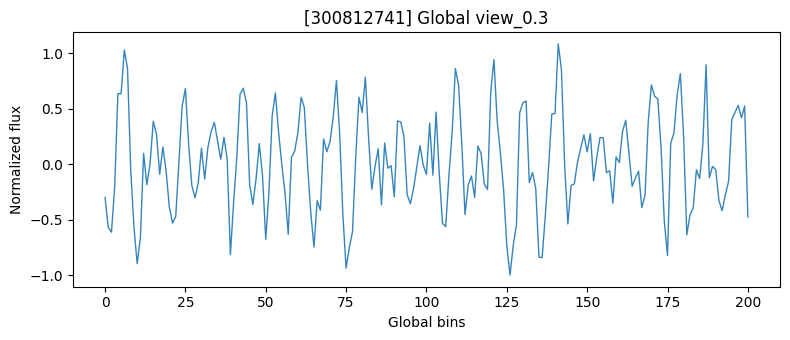

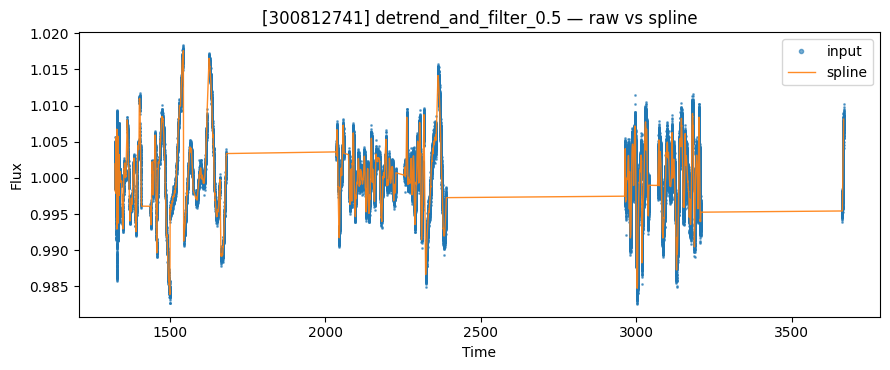

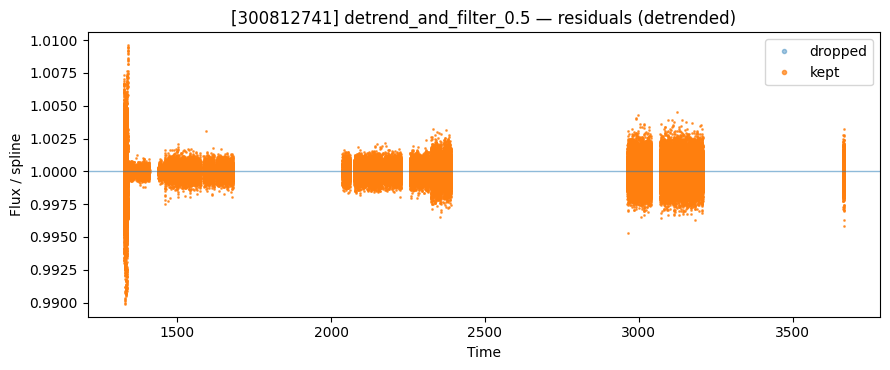

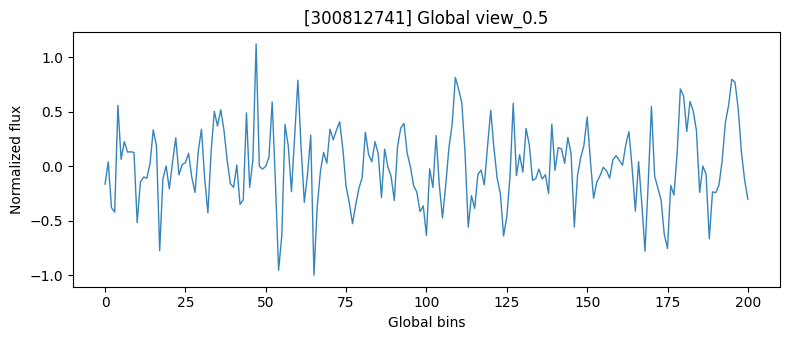

{'_none': array([ 89, 162, 158, ..., 160, 150, 145]),
 '_0.3': array([ 89, 162, 158, ..., 160, 150, 145]),
 '_0.5': array([ 89, 162, 158, ..., 160, 150, 145])}

In [17]:
# Step 2: Generate standard views
from astronet.preprocess.preprocess import filter_outliers, get_spline_mask
from light_curve_util import keplersplinev2


def detrend_and_filter_debug(
    tic_id, time, flux, period, epoch, duration, fixed_bkspace,
    *,
    plot=True,
    title_tag=""
):
    # 1) Build transit mask (in-transit = True)
    input_mask = get_spline_mask(time, period, epoch, duration)
    # 2) Fit spline
    spline_flux, metadata = keplersplinev2.choosekeplersplinev2(
        time,
        flux,
        input_mask=input_mask,
        fixed_bkspace=fixed_bkspace,
        return_metadata=True
    )

    detrended_flux = flux / spline_flux

    # 3) Outlier filtering (keep the mask aligned with filtered arrays)
    detr_time, detr_flux, keep_mask = filter_outliers(time, detrended_flux, input_mask)

    # 4) Plot debug views
    if plot:
        tag = "" if fixed_bkspace is None else f"_{fixed_bkspace}"
        title = f"[{tic_id}] detrend_and_filter{tag}{title_tag}"

        # (a) Raw + spline
        plt.figure(figsize=(9, 3.8))
        plt.plot(time[input_mask], flux[input_mask], ".", markersize=2, alpha=0.6, label="input")
        plt.plot(time, spline_flux, "-", linewidth=1.0, alpha=0.9, label="spline")
        plt.xlabel("Time")
        plt.ylabel("Flux")
        plt.title(f"{title} — raw vs spline")
        plt.legend(loc="best", markerscale=3)
        plt.tight_layout()
        plt.show()

        # (b) Residuals / detrended, highlighting points dropped by outlier filter
        kept = np.isin(time, detr_time)
        plt.figure(figsize=(9, 3.8))
        plt.plot(time[~kept], detrended_flux[~kept], ".", markersize=2, alpha=0.4, label="dropped")
        plt.plot(time[kept],   detrended_flux[kept],   ".", markersize=2, alpha=0.7, label="kept")
        plt.axhline(1.0, lw=1, alpha=0.5)
        plt.xlabel("Time")
        plt.ylabel("Flux / spline")
        plt.title(f"{title} — residuals (detrended)")
        plt.legend(loc="best", markerscale=3)
        plt.tight_layout()
        plt.show()

    return detr_time, detr_flux, input_mask[np.isin(time, detr_time)]

def _debug_plot_global_view(tic, view, tag=""):
    plt.figure(figsize=(8, 3.5))
    x = np.arange(len(view))
    plt.plot(x, view, "-", linewidth=1.0, alpha=0.9)
    plt.xlabel("Global bins")
    plt.ylabel("Normalized flux")
    plt.title(f"[{tic}] Global view{tag}")
    plt.tight_layout()
    plt.show()

def build_global_views_with_debug(
    tic,
    time,
    flux,
    period,
    epoc,
    duration,
    bkspaces=(None, 0.3, 0.5),
):
    """
    Minimal pipeline:
      - detrend_and_filter
      - phase_fold_and_sort_light_curve
      - global_view
    Plus debug visualizations at each of the three steps.
    Returns: dict mapping tag -> fold_num (from the folded call).
    """
    fold_nums_out = {}

    for bkspace in bkspaces:
        tag = "" if bkspace is None else f"_{bkspace}"

        # 1) Detrend + filter
        detrended_time, detrended_flux, transit_mask = detrend_and_filter_debug(
            tic, time, flux, period, epoc, duration, bkspace
        )

        # 2) Phase-fold + sort
        folded_time, folded_flux, fold_num, tr_mask = preprocess.phase_fold_and_sort_light_curve(
            detrended_time, detrended_flux, transit_mask, period, epoc
        )
        fold_nums_out[tag or "_none"] = fold_num

        # 3) Global view on folded data
        view, std, mask, _, _ = preprocess.global_view(tic, folded_time, folded_flux, period)

        # Debug viz #3
        _debug_plot_global_view(tic, view, tag=tag)

    return fold_nums_out

build_global_views_with_debug(tce['TIC ID'],  time, flux, tce.Per, tce.Epoc, tce.Dur)

